/home/santo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/tmp/ipykernel_33589/1682489337.py:66: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({True: 1, False: 0})


Temizlik Sonrası X (Özellikler) Boyutu: (88, 54)
Artık tüm veriler sayısal! Modeli eğitmeye başlıyoruz...

🎉 Modelin Doğruluk Oranı (Accuracy): %72.22


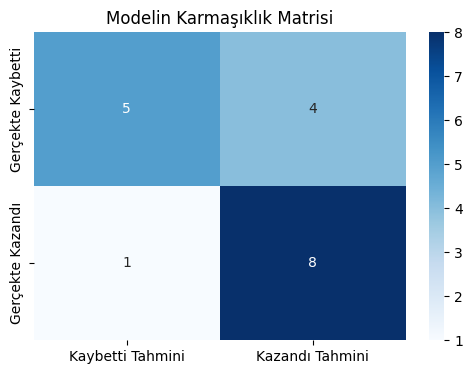

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# ---------------------------------------------------------
# 1. VERİLERİ OKUMA VE BİRLEŞTİRME
# ---------------------------------------------------------
matches_df = pd.read_csv('data/matches.csv')
maps_df = pd.read_csv('data/detailed_matches_maps.csv')
player_df = pd.read_csv('data/detailed_matches_player_stats.csv')

merged_df = pd.merge(matches_df, maps_df, on='match_id', how='inner')

merged_df = merged_df.rename(columns={
	'score_x': 'series_score', 'winner_x': 'series_winner',
	'score_y': 'map_score', 'winner_y': 'map_winner'
})
merged_df = merged_df.drop(columns=['week', 'status'])
merged_df['team1_won_map'] = (merged_df['map_winner'] == merged_df['team1']).astype(int)

# ---------------------------------------------------------
# 2. V2 YENİLİĞİ: VERİ TEMİZLİĞİ (VİRGÜLLÜ AJAN HATASI)
# ---------------------------------------------------------
# Eğer bir satırda "Astra, Omen" yazıyorsa, virgülden böl ve sadece ilk ajanı (Astra) al.
# .strip() ile de kelimenin başındaki/sonundaki boşlukları siliyoruz.
player_df['agent'] = player_df['agent'].astype(str).str.split(',').str[0].str.strip()

# ---------------------------------------------------------
# 3. AJANLARI İŞLEME (One-Hot Encoding)
# ---------------------------------------------------------
agent_picks = player_df[['match_id', 'player_team', 'agent']].rename(columns={'player_team': 'team'})
agent_dummies = pd.get_dummies(agent_picks, columns=['agent'], prefix='', prefix_sep='')
team_agents = agent_dummies.groupby(['match_id', 'team']).max().reset_index()

merged_df = pd.merge(merged_df, team_agents, left_on=['match_id', 'team1'], right_on=['match_id', 'team'], how='left')
merged_df = pd.merge(merged_df, team_agents, left_on=['match_id', 'team2'], right_on=['match_id', 'team'], how='left', suffixes=('_t1', '_t2'))

# ---------------------------------------------------------
# 4. V2 YENİLİĞİ: HARİTA İSİMLERİNİ ÖĞRETME
# ---------------------------------------------------------
# Harita isimlerini 0 ve 1'lere çeviriyoruz (Örn: map_Bind: 1, map_Ascent: 0)
map_dummies = pd.get_dummies(merged_df['map_name'], prefix='map')
# Oluşan yeni harita sütunlarını ana tablomuza ekliyoruz
merged_df = pd.concat([merged_df, map_dummies], axis=1)

# ---------------------------------------------------------
# 5. MODEL GİRDİSİ (X) VE TEMİZLİK
# ---------------------------------------------------------
drop_list = [
	'series_score', 'series_winner', 'map_score', 'map_winner', 'duration', 
	'score1', 'score2', 'team_t1', 'team_t2', 'match_id', 'team1', 'team2', 
	'date', 'time', 'stage', 'picked_by', 'event_name', 'event_stage',
	'map_name' # map_name'in yazılı halini siliyoruz, çünkü üstte 0-1'lere çevirdik
]

existing_drops = [col for col in drop_list if col in merged_df.columns]

X = merged_df.drop(columns=existing_drops + ['team1_won_map', 'match_id', 'score1', 'score2'])  # 'team1_won_map', 'match_id', 'score1', 'score2' sütunlarını da ek olarak siliyoruz
y = merged_df['team1_won_map']

# True/False'ları 1/0'a çevir ve kalan tüm metin sütunlarını sil
X = X.replace({True: 1, False: 0})
X = X.drop(columns=X.select_dtypes(include=['object']).columns)

# ---------------------------------------------------------
# 1. AŞAMA: SON VERİ TEMİZLİĞİ
# ---------------------------------------------------------
# True/False değerlerini 1 ve 0 sayılarına dönüştürüyoruz
X = X.replace({True: 1, False: 0})

# Kalan tüm 'object' (metin) türündeki sütunları bulup siliyoruz
object_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=object_cols)

print("Temizlik Sonrası X (Özellikler) Boyutu:", X.shape)
print("Artık tüm veriler sayısal! Modeli eğitmeye başlıyoruz...\n")

# ---------------------------------------------------------
# 2. AŞAMA: EĞİTİM (TRAIN) VE TEST BÖLÜNMESİ
# ---------------------------------------------------------
# Verimizin %80'ini modele çalışması için (Train), 
# %20'sini ise kopya çekmeden kendini test etmesi için (Test) ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. AŞAMA: MODELİ KURMA VE EĞİTME
# ---------------------------------------------------------
# Güçlü bir Sınıflandırma algoritması olan Random Forest (Rastgele Orman) kullanıyoruz
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Model, X_train verilerine bakarak y_train sonuçlarını öğreniyor
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. AŞAMA: TAHMİN YAPMA VE BAŞARI ÖLÇÜMÜ
# ---------------------------------------------------------
# Modelden hiç görmediği X_test verilerini tahmin etmesini istiyoruz
y_pred = model.predict(X_test)

# Tahminleri gerçek sonuçlarla (y_test) karşılaştırıp başarı oranını buluyoruz
accuracy = accuracy_score(y_test, y_pred)
print(f"🎉 Modelin Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}")

# Modelin nerede kafasının karıştığını görmek için Karmaşıklık Matrisi (Confusion Matrix) çizdiriyoruz
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Kaybetti Tahmini', 'Kazandı Tahmini'], yticklabels=['Gerçekte Kaybetti', 'Gerçekte Kazandı'])
plt.title('Modelin Karmaşıklık Matrisi')
plt.show()

In [2]:
from sklearn.model_selection import GridSearchCV

# Denenecek parametreler
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# En iyi parametreleri bulan araç
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("En İyi Parametreler:", grid_search.best_params_)
model = grid_search.best_estimator_

En İyi Parametreler: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}


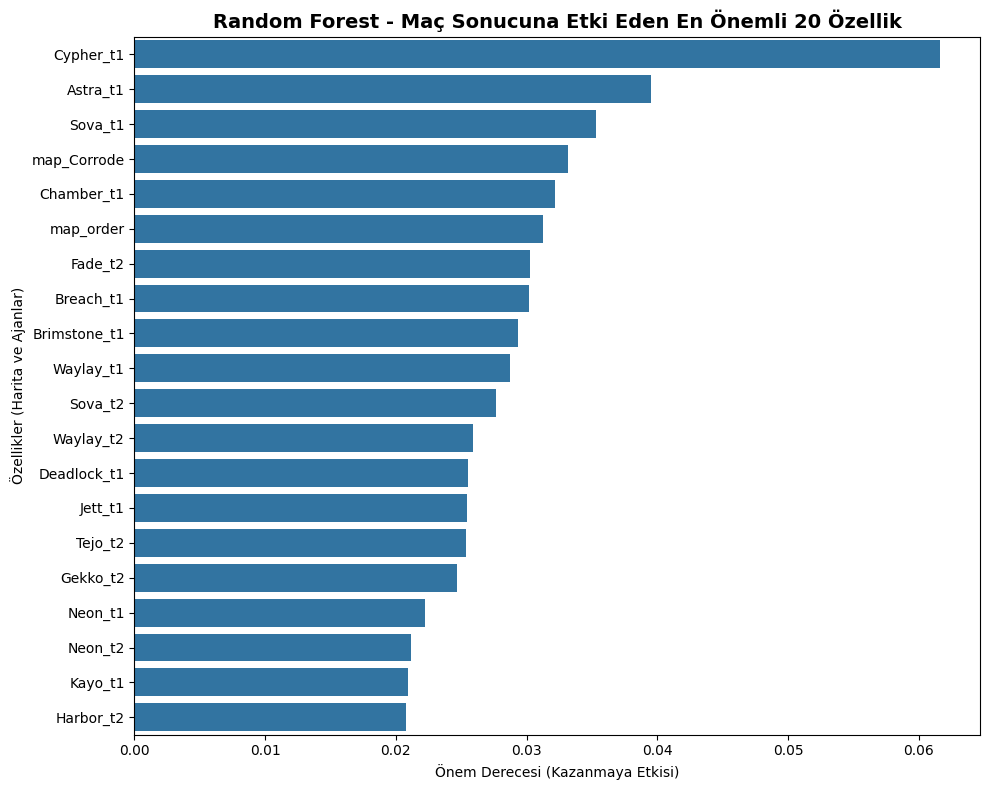

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modelin içindeki önem derecelerini çekelim
importances = model.feature_importances_

# 2. Bu dereceleri, X tablomuzdaki sütun isimleriyle eşleştirelim
feature_imp_df = pd.DataFrame({
    'Özellik': X.columns,
    'Önem_Derecesi': importances
})

# 3. Yüzlerce özellik var, biz en çok etki eden ilk 20'yi bulup sıralayalım
top_20_features = feature_imp_df.sort_values(by='Önem_Derecesi', ascending=False).head(20)

# 4. Veriyi Görselleştirelim
plt.figure(figsize=(10, 8))
sns.barplot(x='Önem_Derecesi', y='Özellik', data=top_20_features)

plt.title('Random Forest - Maç Sonucuna Etki Eden En Önemli 20 Özellik', fontsize=14, fontweight='bold')
plt.xlabel('Önem Derecesi (Kazanmaya Etkisi)')
plt.ylabel('Özellikler (Harita ve Ajanlar)')
plt.tight_layout()
plt.show()

In [4]:
import joblib

# 1. Eğittiğimiz Random Forest modelini kaydedelim
joblib.dump(model, 'valorant_rf_model.pkl')

# 2. ÇOK KRİTİK: Modelin eğitimde gördüğü X tablosunun sütun isimlerini de kaydetmeliyiz.
# Çünkü kullanıcı web arayüzünde sadece 10 ajan seçecek, ancak modelimiz 
# eğitim sırasında yüzlerce '0' ve '1' sütunu gördü. Arayüzde bu yapıyı birebir kurmamız gerekecek.
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model (valorant_rf_model.pkl) ve Sütun Yapısı (model_columns.pkl) başarıyla kaydedildi!")

Model (valorant_rf_model.pkl) ve Sütun Yapısı (model_columns.pkl) başarıyla kaydedildi!


Temizlik Sonrası Özellik Sayısı: 34
Veriler başarıyla sayısallaştırıldı.

🚀 Model V2 Doğruluk Oranı (Accuracy): %72.22
✅ Yeni Model (V2) ve Sütun Yapısı başarıyla kaydedildi!


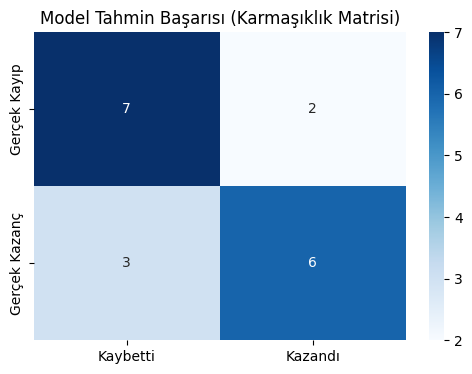

In [5]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. AŞAMA: VERİYİ HAZIRLAMA (X ve y Tanımlama)
# ---------------------------------------------------------
# Hedef değişkenimiz
y = merged_df['team1_won_map']

# X'i oluştururken önce y'yi düşürüyoruz (X burada tanımlanıyor)
X = merged_df.drop(columns=['team1_won_map'])

# ---------------------------------------------------------
# 2. AŞAMA: VERİ TEMİZLİĞİ VE DÖNÜŞTÜRME
# ---------------------------------------------------------
# UYARI ALMAMAK İÇİN: True/False değerlerini direkt astype(int) ile 1/0 yapıyoruz
# select_dtypes(include='bool') ile sadece boolean olanları seçip dönüştürüyoruz
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Kalan tüm 'object' (metin) türündeki sütunları siliyoruz
object_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=object_cols)

print(f"Temizlik Sonrası Özellik Sayısı: {X.shape[1]}")
print("Veriler başarıyla sayısallaştırıldı.\n")

# ---------------------------------------------------------
# 3. AŞAMA: EĞİTİM VE TEST AYRIMI
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 4. AŞAMA: MODELİ KURMA VE EĞİTME
# ---------------------------------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. AŞAMA: DEĞERLENDİRME VE KAYDETME
# ---------------------------------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"🚀 Model V2 Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}")

# Modeli ve Sütun İsimlerini Kaydediyoruz
joblib.dump(model, 'valorant_rf_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')
print("✅ Yeni Model (V2) ve Sütun Yapısı başarıyla kaydedildi!")

# ---------------------------------------------------------
# 6. AŞAMA: GÖRSELLEŞTİRME
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Kaybetti', 'Kazandı'], 
            yticklabels=['Gerçek Kayıp', 'Gerçek Kazanç'])
plt.title('Model Tahmin Başarısı (Karmaşıklık Matrisi)')
plt.show()

In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(f"Ortalama Başarı: %{scores.mean() * 100:.2f}")

Ortalama Başarı: %69.02


Final number of features (columns): 30


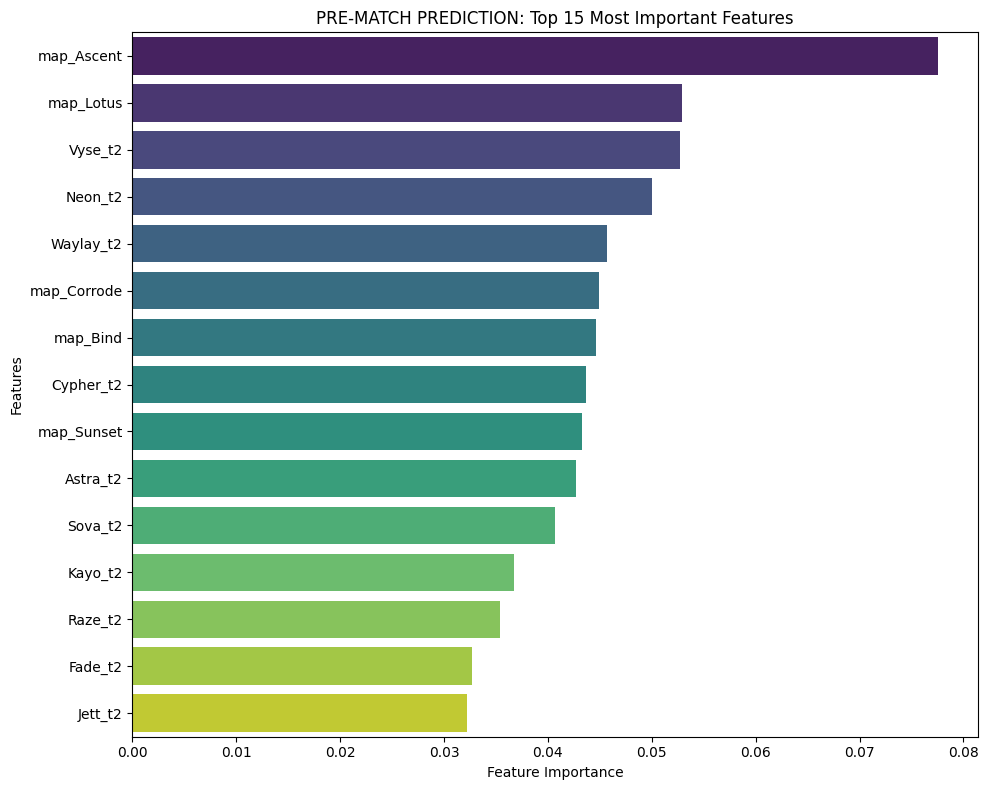

In [7]:
# ========================================
# COMPREHENSIVE MODEL PIPELINE
# (Data Preparation, Training, Visualization)
# ========================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Define X and y
y = merged_df['team1_won_map']
X = merged_df.drop(columns=['team1_won_map', 'match_id', 'score1', 'score2', 'map_order'])

# Step 2: Data Cleaning
# Convert boolean columns to integers
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Identify and drop object (categorical/text) columns
object_cols = X.select_dtypes(include='object').columns
X = X.drop(columns=object_cols)

# Print final number of features
print(f"Final number of features (columns): {X.shape[1]}")

# Step 3: Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 4: Visualization - Top 15 Most Important Features
# Extract top 15 features
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_15_features = feature_importances.head(15)

# Create horizontal bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_15_features.values,
    y=top_15_features.index,
    hue=top_15_features.index,
    palette="viridis",
    legend=False
)
plt.title('PRE-MATCH PREDICTION: Top 15 Most Important Features')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()